# Exercise 6: Euler-backward method for decay


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
#submission folder
main_folder = Path("Baliti_Ocean Modelling Exercises")
figures_folder = main_folder / "Figures"
figures_folder.mkdir(parents=True, exist_ok=True)

In [3]:
#Model boundry conditions
t0 = 0.0
tn = 20.0
kappa = 0.05
C0 = 0.5

In [4]:
#defining for Euler-backward
def euler_backward(dt):
    nsteps = int(np.floor((tn - t0)/dt) + 1)
    t = np.zeros(nsteps)
    C = np.zeros(nsteps)
    t[0] = t0
    C[0] = C0
    for n in range(nsteps - 1):
        C[n+1] = C[n] / (1 + kappa*dt)     #Euler-backward
        t[n+1] = t[n] + dt
    return t, C

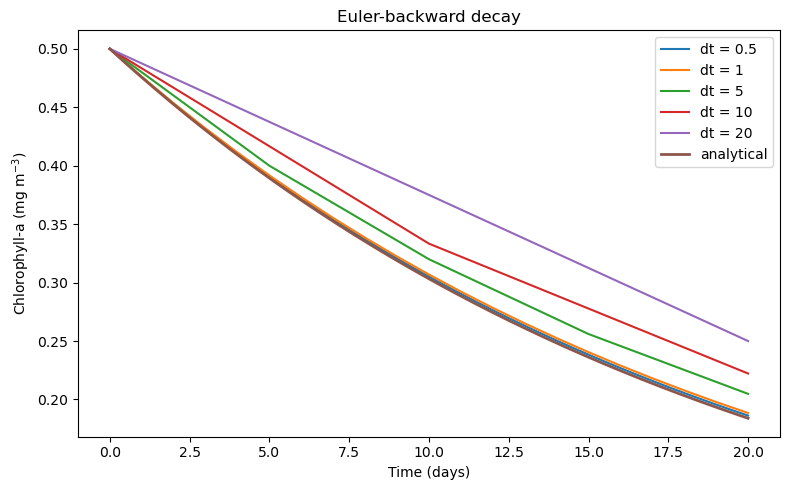

In [5]:
plt.figure(figsize=(8, 5))
for dt in [0.5, 1, 5, 10, 20]:
    t, C = euler_backward(dt)
    plt.plot(t, C, label=f'dt = {dt}')

t_exact = np.linspace(t0, tn, 300)
C_exact = C0 * np.exp(-kappa*t_exact)
plt.plot(t_exact, C_exact, linewidth=2, label='analytical')

plt.xlabel('Time (days)')
plt.ylabel('Chlorophyll-a (mg m$^{-3}$)')
plt.title('Euler-backward decay')
plt.legend()
plt.tight_layout()
plt.savefig(figures_folder / 'ex6_euler_backward.png', dpi=200)
plt.show()